In [ ]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML/ACDC_radiomics.csv")

df.head()

,original_shape_Elongation_LV_ED,original_shape_Flatness_LV_ED,original_shape_LeastAxisLength_LV_ED,original_shape_MajorAxisLength_LV_ED,original_shape_Maximum2DDiameterColumn_LV_ED,original_shape_Maximum2DDiameterRow_LV_ED,original_shape_Maximum2DDiameterSlice_LV_ED,original_shape_Maximum3DDiameter_LV_ED,original_shape_MeshVolume_LV_ED,original_shape_MinorAxisLength_LV_ED,...,original_glszm_ZonePercentage_MYO_ES,original_glszm_ZoneVariance_MYO_ES,original_ngtdm_Busyness_MYO_ES,original_ngtdm_Coarseness_MYO_ES,original_ngtdm_Complexity_MYO_ES,original_ngtdm_Contrast_MYO_ES,original_ngtdm_Strength_MYO_ES,height,weight,class
0,0.560917,0.110560,6.592758,59.630582,45.398238,64.776539,64.007812,65.199693,5674.000000,33.447817,...,0.053567,40384.123570,19.552355,0.000993,36.034390,0.010496,0.091329,184,95,DCM
1,0.454960,0.088323,5.730218,64.877933,40.311289,64.140471,61.000000,67.446275,5015.833333,29.516875,...,0.028344,130808.332098,29.225756,0.000722,17.238110,0.006596,0.045024,160,70,DCM
2,0.541682,0.105418,6.711577,63.666027,48.041649,66.843100,59.135438,68.080834,7817.666667,34.486772,...,0.041404,92088.926893,20.732684,0.001106,13.916093,0.004455,0.069372,165,77,DCM
3,0.487949,0.105906,6.726159,63.510529,44.407207,66.370174,66.007575,66.475559,5629.166667,30.989912,...,0.150855,5232.431686,5.158496,0.000848,216.183657,0.025431,0.208797,159,46,DCM
4,0.442150,0.095225,7.186765,75.471150,68.066144,77.472576,50.487622,77.472576,8550.083333,33.369563,...,0.040613,91705.803093,18.086404,0.000710,41.886924,0.005266,0.123346,165,77,DCM


In [ ]:
print('El número de muestras del dataset es {}.'.format(df.shape[0]))

El número de muestras del dataset es 100.


# EXPLORATORY ANALYSIS (EDA)

In [ ]:
df.isnull().sum()

,0
original_shape_Elongation_LV_ED,0
original_shape_Flatness_LV_ED,0
original_shape_LeastAxisLength_LV_ED,0
original_shape_MajorAxisLength_LV_ED,0
original_shape_Maximum2DDiameterColumn_LV_ED,0
...,...
original_ngtdm_Contrast_MYO_ES,0
original_ngtdm_Strength_MYO_ES,0
height,0
weight,0


In [ ]:
train_df, test_df = train_test_split(df, test_size = 0.2, random_state=0)

In [ ]:
print(train_df.shape, test_df.shape)

(80, 645) (20, 645)


In [ ]:
train_df.describe()

,original_shape_Elongation_LV_ED,original_shape_Flatness_LV_ED,original_shape_LeastAxisLength_LV_ED,original_shape_MajorAxisLength_LV_ED,original_shape_Maximum2DDiameterColumn_LV_ED,original_shape_Maximum2DDiameterRow_LV_ED,original_shape_Maximum2DDiameterSlice_LV_ED,original_shape_Maximum3DDiameter_LV_ED,original_shape_MeshVolume_LV_ED,original_shape_MinorAxisLength_LV_ED,...,original_glszm_ZoneEntropy_MYO_ES,original_glszm_ZonePercentage_MYO_ES,original_glszm_ZoneVariance_MYO_ES,original_ngtdm_Busyness_MYO_ES,original_ngtdm_Coarseness_MYO_ES,original_ngtdm_Complexity_MYO_ES,original_ngtdm_Contrast_MYO_ES,original_ngtdm_Strength_MYO_ES,height,weight
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,...,80.000000,80.000000,8.000000e+01,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,0.559414,0.117281,7.018709,61.564652,47.772872,67.625087,62.673520,68.603297,7724.548958,34.043758,...,4.321855,0.031555,2.129640e+05,41.057962,0.001545,24.402429,0.013287,0.057519,170.600000,74.650000
std,0.081495,0.046164,2.423232,11.953856,11.375756,13.348688,14.575164,13.381458,4390.937484,6.059736,...,0.661245,0.032633,4.474491e+05,32.978301,0.000712,67.645400,0.010320,0.087695,10.120289,17.411694
min,0.382027,0.046936,3.365035,41.204891,21.095023,46.043458,39.012818,47.053161,1984.375000,21.095961,...,3.193796,0.003233,3.176649e+02,1.770204,0.000443,1.399527,0.001240,0.004716,140.000000,35.000000
25%,0.503445,0.089842,5.547015,53.767477,40.311289,59.920623,53.007075,60.203817,5091.822917,30.218074,...,3.915891,0.014116,5.457231e+04,19.564403,0.001058,2.765045,0.008052,0.012007,164.500000,61.000000
50%,0.562540,0.104781,6.491829,61.729255,45.541190,66.471721,61.163575,67.646128,6623.020833,33.344347,...,4.215808,0.022317,1.170565e+05,33.105185,0.001417,4.351720,0.010025,0.022000,170.000000,74.000000
75%,0.600633,0.126306,7.407016,66.319998,53.235327,73.649261,69.255434,74.451149,9282.125000,36.883904,...,4.664046,0.031464,2.237611e+05,54.495522,0.001819,12.952419,0.015435,0.057855,178.250000,84.250000
max,0.791923,0.286265,14.860626,131.551946,90.138782,143.391074,139.003597,144.371050,26335.375000,59.645360,...,6.251883,0.205567,3.806504e+06,185.157865,0.004126,515.368502,0.066583,0.450330,192.000000,123.000000


#Analysis to identify null or 0 Values

In [ ]:
print("Porcentaje de registros con original_shape_Elongation_LV_ED 0:",(len(train_df[train_df["original_shape_Elongation_LV_ED"] == 0])/len(train_df))*100)
print("Porcentaje de registros con Poriginal_shape_Flatness_LV_ED 0:",(len(train_df[train_df["original_shape_Flatness_LV_ED"] == 0])/len(train_df))*100)
print("Porcentaje de registros con original_shape_LeastAxisLength_LV_ED:",(len(train_df[train_df["original_shape_LeastAxisLength_LV_ED"] == 0])/len(train_df))*100)
print("Porcentaje de registros con original_shape_MajorAxisLength_LV_ED 0:",(len(train_df[train_df["original_shape_MajorAxisLength_LV_ED"] == 0])/len(train_df))*100)
print("Porcentaje de registros con original_shape_Maximum2DDiameterColumn_LV_ED 0:",(len(train_df[train_df["original_shape_Maximum2DDiameterColumn_LV_ED"] == 0])/len(train_df))*100)
print("Porcentaje de registros con original_shape_Maximum2DDiameterRow_LV_ED 0:",(len(train_df[train_df["original_shape_Maximum2DDiameterRow_LV_ED"] == 0])/len(train_df))*100)
print("Porcentaje de registros con original_shape_Maximum2DDiameterSlice_LV_ED 0:",(len(train_df[train_df["original_shape_Maximum2DDiameterSlice_LV_ED"] == 0])/len(train_df))*100)

Porcentaje de registros con original_shape_Elongation_LV_ED 0: 0.0
Porcentaje de registros con Poriginal_shape_Flatness_LV_ED 0: 0.0
Porcentaje de registros con original_shape_LeastAxisLength_LV_ED: 0.0
Porcentaje de registros con original_shape_MajorAxisLength_LV_ED 0: 0.0
Porcentaje de registros con original_shape_Maximum2DDiameterColumn_LV_ED 0: 0.0
Porcentaje de registros con original_shape_Maximum2DDiameterRow_LV_ED 0: 0.0
Porcentaje de registros con original_shape_Maximum2DDiameterSlice_LV_ED 0: 0.0


# Explore the variable original_shape_Elongation_LV_ED

In [ ]:
print(train_df["original_shape_Elongation_LV_ED"].min(), train_df["original_shape_Elongation_LV_ED"].max())

0.3820267321008667 0.7919228559452863


# Correlation Variables

In [ ]:
X = train_df.drop("class", axis = 1)
y = train_df["class"]
X_test = test_df.drop("class", axis = 1)
y_test = test_df["class"]

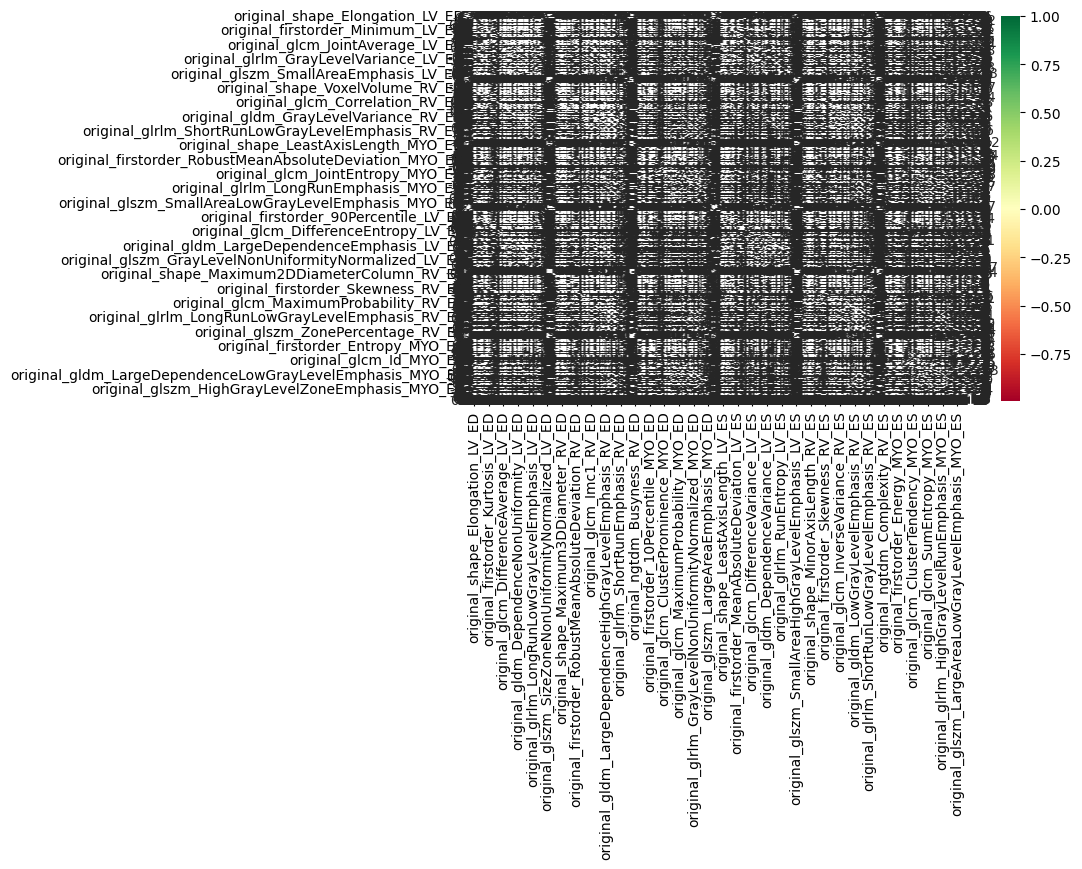

In [ ]:
plt.subplots(figsize=(8, 5))
sns.heatmap(X.corr(), annot=True, cmap="RdYlGn")
plt.show()

# Classification Models

In [ ]:
# Cargamos las librerías
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, log_loss, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [31]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    balanced_accuracy_score, log_loss
)

In [ ]:
# Seleccionamos las variables predictoras y la variable objetivo
# Dividimos el conjunto de entrenamiento en train y val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=2)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_val = sc_X.transform(X_val)

### K-NN

In [ ]:
classifier = KNeighborsClassifier(n_neighbors = 5, metric = "minkowski", p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred  = classifier.predict(X_val)

In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         DCM       0.67      0.67      0.67         6
         HCM       0.50      0.25      0.33         4
        MINF       0.25      0.50      0.33         4
         NOR       0.40      0.29      0.33         7
          RV       1.00      1.00      1.00         3

    accuracy                           0.50        24
   macro avg       0.56      0.54      0.53        24
weighted avg       0.53      0.50      0.50        24



In [ ]:
confusion_matrix(y_val, y_pred)

array([[4, 0, 2, 0, 0],
       [0, 1, 1, 2, 0],
       [1, 0, 2, 1, 0],
       [1, 1, 3, 2, 0],
       [0, 0, 0, 0, 3]])

In [ ]:
conf=pd.DataFrame(
    confusion_matrix(y_val, y_pred),
    columns=['DCM', 'HCM','MINF','NOR','RV'],
    index  =['DCM', 'HCM','MINF','NOR','RV']
)
print(conf)

      DCM  HCM  MINF  NOR  RV
DCM     4    0     2    0   0
HCM     0    1     1    2   0
MINF    1    0     2    1   0
NOR     1    1     3    2   0
RV      0    0     0    0   3


In [ ]:
accuracy_score(y_val, y_pred)

0.5

In [32]:
# For class predictions (imbalanced data)
bal_acc = balanced_accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')

### NB

In [38]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [39]:
y_pred  = classifier.predict(X_val)

In [40]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         DCM       0.00      0.00      0.00         6
         HCM       0.00      0.00      0.00         4
        MINF       0.00      0.00      0.00         4
         NOR       0.50      0.29      0.36         7
          RV       0.30      1.00      0.46         3

    accuracy                           0.21        24
   macro avg       0.16      0.26      0.17        24
weighted avg       0.18      0.21      0.16        24



In [41]:
confusion_matrix(y_val, y_pred)

array([[0, 1, 4, 0, 1],
       [0, 0, 1, 2, 1],
       [1, 1, 0, 0, 2],
       [0, 2, 0, 2, 3],
       [0, 0, 0, 0, 3]])

In [43]:
conf=pd.DataFrame(
    confusion_matrix(y_val, y_pred),
    columns=['DCM', 'HCM','MINF','NOR','RV'],
    index  =['DCM', 'HCM','MINF','NOR','RV']
)
print(conf)

      DCM  HCM  MINF  NOR  RV
DCM     0    1     4    0   1
HCM     0    0     1    2   1
MINF    1    1     0    0   2
NOR     0    2     0    2   3
RV      0    0     0    0   3


In [44]:
accuracy_score(y_val, y_pred)

0.20833333333333334

### SVM

In [47]:
classifier = SVC(C=10, gamma = 0.08, kernel = 'rbf')
classifier.fit(X_train, y_train)

SVC(C=10, gamma=0.08)

In [48]:
y_pred  = classifier.predict(X_val)

In [49]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         DCM       0.00      0.00      0.00         6
         HCM       0.00      0.00      0.00         4
        MINF       0.67      0.50      0.57         4
         NOR       0.00      0.00      0.00         7
          RV       0.14      1.00      0.25         3

    accuracy                           0.21        24
   macro avg       0.16      0.30      0.16        24
weighted avg       0.13      0.21      0.13        24



In [50]:
confusion_matrix(y_val, y_pred)

array([[0, 0, 1, 0, 5],
       [0, 0, 0, 0, 4],
       [0, 0, 2, 0, 2],
       [0, 0, 0, 0, 7],
       [0, 0, 0, 0, 3]])

In [52]:
conf=pd.DataFrame(
    confusion_matrix(y_val, y_pred),
    columns=['DCM', 'HCM','MINF','NOR','RV'],
    index  =['DCM', 'HCM','MINF','NOR','RV']
)
print(conf)

      DCM  HCM  MINF  NOR  RV
DCM     0    0     1    0   5
HCM     0    0     0    0   4
MINF    0    0     2    0   2
NOR     0    0     0    0   7
RV      0    0     0    0   3


In [53]:
accuracy_score(y_val, y_pred)

0.20833333333333334

### MEJOR MODELO